## Importing Libraries

In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from collections import Counter
from collections import defaultdict

### Import Dataset

In [2]:
meta = pd.read_csv("ECG_Processed_Dataset/ecg_meta.csv")
signals = np.load("ECG_Processed_Dataset/ecg_signals.npy", allow_pickle=True)

meta["signal"] = signals
df = meta

In [3]:
df

,record_id,label,length,signal
0,A00001,N,9000,"[-0.127, -0.162, -0.197, -0.229, -0.245, -0.25..."
1,A00002,N,9000,"[0.128, 0.157, 0.189, 0.226, 0.25, 0.257, 0.26..."
2,A00003,N,18000,"[0.056, 0.073, 0.085, 0.093, 0.1, 0.107, 0.113..."
3,A00004,A,9000,"[0.519, 0.619, 0.723, 0.827, 0.914, 0.956, 0.9..."
4,A00005,A,18000,"[-0.188, -0.239, -0.274, -0.316, -0.356, -0.37..."
...,...,...,...,...
8523,A08524,N,9000,"[-0.104, -0.127, -0.144, -0.154, -0.16, -0.164..."
8524,A08525,O,9000,"[-0.121, -0.197, -0.288, -0.39, -0.496, -0.6, ..."
8525,A08526,N,10904,"[-0.202, -0.235, -0.272, -0.305, -0.325, -0.33..."
8526,A08527,N,9000,"[-0.227, -0.297, -0.374, -0.449, -0.505, -0.52..."


## Convert Signals to Fixed Windows

### Checking Record Lengths

In [4]:
length_counts = dict(Counter(df["length"]))

print("Number of unique signal lengths:", len(length_counts))
print("Sample of length counts:")
for length, count in list(length_counts.items()):
    print(f"Length {length}: {count} records")

Number of unique signal lengths: 1487
Sample of length counts:
Length 9000: 5977 records
Length 18000: 809 records
Length 5570: 1 records
Length 6102: 2 records
Length 11520: 3 records
Length 8694: 2 records
Length 14936: 1 records
Length 17800: 1 records
Length 6542: 1 records
Length 6982: 2 records
Length 14054: 2 records
Length 8141: 1 records
Length 17574: 1 records
Length 3002: 1 records
Length 18170: 1 records
Length 5048: 1 records
Length 7028: 1 records
Length 3760: 2 records
Length 5144: 1 records
Length 17020: 1 records
Length 3028: 1 records
Length 6166: 1 records
Length 3238: 1 records
Length 5866: 1 records
Length 4568: 2 records
Length 6174: 1 records
Length 3306: 1 records
Length 8802: 1 records
Length 5140: 2 records
Length 4072: 4 records
Length 5288: 2 records
Length 13110: 1 records
Length 7240: 2 records
Length 5878: 1 records
Length 6054: 1 records
Length 17990: 1 records
Length 12696: 1 records
Length 3742: 1 records
Length 8606: 1 records
Length 8158: 1 records
L

In [5]:
count_to_lengths = defaultdict(list)

for length, count in length_counts.items():
    count_to_lengths[count].append(length)


In [6]:
print(count_to_lengths.keys())

dict_keys([5977, 809, 1, 2, 3, 4])


In [7]:
for count in sorted(count_to_lengths.keys()):
    print(f"{count} record(s): {len(count_to_lengths[count])} unique lengths")


1 record(s): 1263 unique lengths
2 record(s): 193 unique lengths
3 record(s): 23 unique lengths
4 record(s): 6 unique lengths
809 record(s): 1 unique lengths
5977 record(s): 1 unique lengths


In [8]:
print("Lengths with exactly 5977 records:")
print(count_to_lengths[5977])

print("\nLengths with exactly 809 records:")
print(count_to_lengths[809])

print("\nLengths with exactly 1 record:")
print(count_to_lengths[1])

print("\nLengths with exactly 2 records:")
print(count_to_lengths[2])

print("\nLengths with exactly 3 records:")
print(count_to_lengths[3])

print("\nLengths with exactly 4 records:")
print(count_to_lengths[4])

Lengths with exactly 5977 records:
[9000]

Lengths with exactly 809 records:
[18000]

Lengths with exactly 1 record:
[5570, 14936, 17800, 6542, 8141, 17574, 3002, 18170, 5048, 7028, 5144, 17020, 3028, 6166, 3238, 5866, 6174, 3306, 8802, 13110, 5878, 6054, 17990, 12696, 3742, 8606, 8158, 6878, 6206, 4562, 5478, 8722, 6986, 5826, 4414, 17130, 3898, 3020, 6344, 6300, 15492, 8162, 3844, 3972, 12636, 5264, 5544, 7586, 6230, 4198, 3998, 12310, 9592, 7800, 8636, 8806, 3776, 3044, 2996, 5718, 8172, 4702, 5472, 4130, 7682, 6150, 3858, 17992, 5810, 11648, 7934, 4972, 6716, 5946, 15266, 5912, 9508, 7056, 17862, 6140, 9020, 3978, 8288, 4028, 6114, 4580, 3256, 5074, 3560, 3682, 2868, 10052, 7528, 4116, 16714, 4448, 3464, 2808, 8364, 3022, 3220, 3786, 10184, 14074, 7856, 3034, 4610, 3346, 2902, 12422, 8006, 5392, 7530, 9658, 6550, 11398, 13534, 3202, 7354, 5918, 14148, 5186, 9482, 5729, 5290, 7284, 6900, 8368, 6258, 8400, 4070, 3128, 5608, 18260, 3372, 5904, 7912, 4316, 8322, 18034, 2796, 5006, 9512

### Handling Variable Record Lengths

In [9]:
WINDOW_SIZE = 9000

In [10]:
def create_windows(signal, window_size=9000):
    """
    Splits a 1D ECG signal into fixed-length windows.
    Pads if signal is shorter than window_size.
    """
    windows = []
    length = len(signal)

    if length < window_size:
        padded = np.zeros(window_size)
        padded[:length] = signal
        windows.append(padded)
    else:
        for start in range(0, length - window_size + 1, window_size):
            window = signal[start:start + window_size]
            windows.append(window)

    return windows


In [11]:
windowed_records = []

for _, row in df.iterrows():
    signal = row["signal"]
    label = row["label"]
    record_id = row["record_id"]

    # Z-score normalization
    signal = (signal - np.mean(signal)) / (np.std(signal) + 1e-8)

    windows = create_windows(signal, WINDOW_SIZE)

    for i, w in enumerate(windows):
        windowed_records.append({
            "record_id": record_id,
            "window_id": i,
            "label": label,
            "signal": w
        })


In [12]:
windowed_df = pd.DataFrame(windowed_records)

print("Total windows:", len(windowed_df))
windowed_df.head()


Total windows: 9376


,record_id,window_id,label,signal
0,A00001,0,N,"[-0.864847801274676, -1.072787545498718, -1.28..."
1,A00002,0,N,"[0.6043533214359804, 0.7685190906833443, 0.949..."
2,A00003,0,N,"[0.42090414235866846, 0.5348628202637852, 0.61..."
3,A00003,1,N,"[0.15276607669957007, 0.15946952834104752, 0.1..."
4,A00004,0,A,"[2.2397562185223023, 2.707878323598838, 3.1947..."


In [13]:
windowed_df['signal'][0]

array([-0.8648478 , -1.07278755, -1.28072729, ..., -0.21726403,
       -0.24102857, -0.23508743], shape=(9000,))

In [14]:
label_encoding = {
    "N": 0,
    "AF": 1,
    "O": 2,
    "~": 3
}

windowed_df["label_id"] = windowed_df["label"].map(label_encoding)

### Save

In [ ]:
signals = np.stack(windowed_df["signal"].values)
meta = windowed_df.drop(columns=["signal"])

In [16]:
np.save("ECG_Processed_Dataset/windowed_signals_9000.npy", signals)
meta.to_csv("ECG_Processed_Dataset/windowed_metadata.csv", index=False)

### Reload

In [17]:
signals = np.load("ECG_Processed_Dataset/windowed_signals_9000.npy")
meta = pd.read_csv("ECG_Processed_Dataset/windowed_metadata.csv")

meta["signal"] = list(signals)
windowed_df = meta

In [18]:
windowed_df

,record_id,window_id,label,label_id,signal
0,A00001,0,N,0.0,"[-0.864847801274676, -1.072787545498718, -1.28..."
1,A00002,0,N,0.0,"[0.6043533214359804, 0.7685190906833443, 0.949..."
2,A00003,0,N,0.0,"[0.42090414235866846, 0.5348628202637852, 0.61..."
3,A00003,1,N,0.0,"[0.15276607669957007, 0.15946952834104752, 0.1..."
4,A00004,0,A,NaN,"[2.2397562185223023, 2.707878323598838, 3.1947..."
...,...,...,...,...,...
9371,A08524,0,N,0.0,"[-1.8868168948556805, -2.271787061141514, -2.5..."
9372,A08525,0,O,2.0,"[-0.17081191205058835, -0.41130887348926887, -..."
9373,A08526,0,N,0.0,"[-1.2866328515666983, -1.4831286761972158, -1...."
9374,A08527,0,N,0.0,"[-1.1545600565588832, -1.506429297777834, -1.8..."


## NeuroKit2

In [2]:
!pip install neurokit2

  Using cached pandas-2.3.3-cp312-cp312-win_amd64.whl.metadata (19 kB)
  Using cached requests-2.32.5-py3-none-any.whl.metadata (4.9 kB)
  Using cached charset_normalizer-3.4.4-cp312-cp312-win_amd64.whl.metadata (38 kB)
  Using cached idna-3.11-py3-none-any.whl.metadata (8.4 kB)
  Using cached urllib3-2.6.3-py3-none-any.whl.metadata (6.9 kB)
   ---------------------------------------- 0.0/688.9 kB ? eta -:--:--
   ---------------------------------------- 688.9/688.9 kB 6.8 MB/s  0:00:00
Using cached pandas-2.3.3-cp312-cp312-win_amd64.whl (11.0 MB)
   ---------------------------------------- 0.0/1.1 MB ? eta -:--:--
   ---------------------------------------  1.0/1.1 MB 6.3 MB/s eta 0:00:01
   ---------------------------------------- 1.1/1.1 MB 5.7 MB/s  0:00:00
   ---------------------------------------- 0.0/4.2 MB ? eta -:--:--
   ------------ --------------------------- 1.3/4.2 MB 6.1 MB/s eta 0:00:01
   ------------------------ --------------- 2.6/4.2 MB 6.3 MB/s eta 0:00:01
   ----

In [3]:
import neurokit2 as nk

In [4]:
def extract_ecg_features(ecg_signal, fs, min_peaks=5):
    """
    Extract ECG features using NeuroKit2.
    Returns None if signal is not physiologically usable.
    """

    # Clean ECG
    ecg_cleaned = nk.ecg_clean(ecg_signal, sampling_rate=fs)

    # Detect R-peaks
    signals, info = nk.ecg_peaks(ecg_cleaned, sampling_rate=fs)
    r_peaks = info["ECG_R_Peaks"]

    # Skip if too few peaks
    if len(r_peaks) < min_peaks:
        return None

    # Heart rate
    heart_rate = nk.ecg_rate(signals, sampling_rate=fs)

    # HRV features
    hrv_features = nk.hrv(
        signals,
        sampling_rate=fs,
        show=False
    )

    features = hrv_features.iloc[0].to_dict()

    # Add simple stats
    features.update({
        "hr_mean": heart_rate.mean(),
        "hr_std": heart_rate.std(),
        "rr_count": len(r_peaks)
    })

    return features


In [9]:
feature_rows = []

for idx, row in df.iterrows():
    features = extract_ecg_features(row["signal"], fs)

    if features is None:
        continue  # Skip bad windows

    features["label"] = row["label"]
    feature_rows.append(features)

features_df = pd.DataFrame(feature_rows)
print(features_df.shape)


NameError: name 'fs' is not defined

In [10]:
features_df = pd.DataFrame(feature_rows)
print(features_df.shape)


(0, 0)


In [ ]:
# Remove columns with too many NaNs
features_df = features_df.dropna(axis=1, thresh=int(0.7 * len(features_df)))

# Fill remaining NaNs
features_df = features_df.fillna(features_df.median(numeric_only=True))

In [ ]:
from sklearn.model_selection import train_test_split
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import classification_report

X = features_df.drop(columns=["label"])
y = features_df["label"]

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, stratify=y, random_state=42
)

model = RandomForestClassifier(
    n_estimators=300,
    class_weight=class_weight_dict,
    random_state=42
)

model.fit(X_train, y_train)
y_pred = model.predict(X_test)

print(classification_report(y_test, y_pred))

## Class Distribution

In [ ]:
record_level_counts = (
    df[["record_id", "label"]]
    .drop_duplicates()
    .value_counts("label")
    .sort_index()
)

In [ ]:
window_level_counts = (
    windowed_df
    .value_counts("label")
    .sort_index()
)

In [ ]:
class_summary = pd.DataFrame({
    "record_count": record_level_counts,
    "window_count": window_level_counts,
    "percentage": (window_level_counts / window_level_counts.sum()) * 100
}).fillna(0)

print("Class imbalance summary:")
print(class_summary)


Class imbalance summary:
       record_count  window_count  percentage
label                                        
A               738           831    8.863055
N              5050          5458   58.212457
O              2456          2797   29.831485
~               284           290    3.093003


# New Data Augmentation and Preprocessing

In [4]:
import numpy as np
import pandas as pd
from scipy.signal import butter, filtfilt
import sklearn
from sklearn.model_selection import train_test_split
from collections import Counter

In [ ]:
WINDOW_SIZE = 4500 # 15 s (at 300 Hz)
STEP_SIZE = 2250 # 50% overlap
FS = 300
RANDOM_STATE = 42

label_encoding = {"N": 0, "A": 1, "O": 2, "~": 3}

## Train Test Split (done at record level)

In [ ]:
record_ids   = df["record_id"].values
record_labels = df["label"].values

train_ids, test_ids = train_test_split(
    record_ids,
    test_size=0.2,
    random_state=RANDOM_STATE,
    stratify=record_labels # preserve class ratio in both splits
)

train_df = df[df["record_id"].isin(train_ids)].reset_index(drop=True)
test_df  = df[df["record_id"].isin(test_ids)].reset_index(drop=True)

print(f"Train records: {len(train_df)} | Test records: {len(test_df)}")
print("Train label distribution:", Counter(train_df["label"]))
print("Test label distribution:", Counter(test_df["label"]))

Train records: 6822 | Test records: 1706
Train label distribution: Counter({'N': 4040, 'O': 1965, 'A': 590, '~': 227})
Test label distribution: Counter({'N': 1010, 'O': 491, 'A': 148, '~': 57})


## Signal Processing Functions

In [ ]:
def bandpass_filter(signal, lowcut=0.5, highcut=45.0, fs=300, order=2):
    """2nd-order Butterworth bandpass filter — removes baseline wander & HF noise"""
    nyq = fs / 2.0
    low, high = lowcut / nyq, highcut / nyq
    b, a = butter(order, [low, high], btype="band")
    return filtfilt(b, a, signal)

def z_score_normalize(signal):
    return (signal - np.mean(signal)) / (np.std(signal) + 1e-8)

def preprocess_signal(signal):
    signal = bandpass_filter(signal)
    signal = z_score_normalize(signal)
    return signal

## Create Overlapping windows

In [ ]:
def create_windows(signal, window_size=WINDOW_SIZE, step_size=STEP_SIZE):
    """Overlapping sliding windows. Pad if signal is shorter than window size"""
    windows = []
    length  = len(signal)

    if length < window_size:
        padded = np.zeros(window_size) 
        padded[:length] = signal
        windows.append(padded)
        return windows

    for start in range(0, length - window_size + 1, step_size):
        windows.append(signal[start : start + window_size])

    return windows

def build_windowed_dataset(source_df):
    records = []
    for _, row in source_df.iterrows():
        signal    = preprocess_signal(row["signal"])
        label     = row["label"]
        record_id = row["record_id"]

        for i, w in enumerate(create_windows(signal)):
            records.append({
                "record_id": record_id,
                "window_id": i,
                "label":     label,
                "label_id":  label_encoding[label],
                "signal":    w
            })
    return pd.DataFrame(records)

print("Building windowed train set...")
train_windowed = build_windowed_dataset(train_df)

print("Building windowed test set...")
test_windowed  = build_windowed_dataset(test_df)   # NO augmentation on test set

print("Train window distribution:", Counter(train_windowed["label"]))
print("Test  window distribution:", Counter(test_windowed["label"]))

Building windowed train set...
Building windowed test set...
Train window distribution: Counter({'N': 13028, 'O': 6942, 'A': 1906, '~': 495})
Test  window distribution: Counter({'N': 3220, 'O': 1696, 'A': 498, '~': 134})


## Data Augmentation

### Functions

In [ ]:
def augment_gaussian_noise(signal, noise_factor=0.02):
    """Add small Gaussian noise — simulates sensor variability."""
    noise = np.random.normal(0, noise_factor, size=signal.shape)
    return signal + noise

def augment_amplitude_scale(signal, scale_range=(0.8, 1.2)):
    """Randomly scale amplitude — simulates inter-patient voltage differences."""
    scale = np.random.uniform(*scale_range)
    return signal * scale

def augment_time_shift(signal, max_shift_ratio=0.1):
    """Circular time shift — preserves rhythm while changing phase."""
    max_shift = int(len(signal) * max_shift_ratio)
    shift     = np.random.randint(-max_shift, max_shift)
    return np.roll(signal, shift)

def augment_baseline_wander(signal, fs=FS, max_amp=0.1):
    """Add slow sinusoidal baseline wander (0.05-0.5 Hz)."""
    freq = np.random.uniform(0.05, 0.5)
    t    = np.arange(len(signal)) / fs
    wander = max_amp * np.sin(2 * np.pi * freq * t + np.random.uniform(0, 2*np.pi))
    return signal + wander

def augment_ecg_cutmix(signal_a, signal_b, num_segments=2):
    """
    ECG CutMix: randomly splice segments from signal b into signal a.
    Both signals must be same-class (label-preserving).
    Segment boundaries chosen to avoid abrupt discontinuities via linear blending.
    """
    result     = signal_a.copy()
    seg_length = len(signal_a) // (num_segments * 3) # variable segment size

    for _ in range(num_segments):
        length = np.random.randint(seg_length // 2, seg_length * 2)
        start  = np.random.randint(0, len(signal_a) - length)

        # Linear blend at boundaries (3% of segment length) for continuity
        blend = max(1, int(length * 0.03))
        patch = signal_b[start : start + length].copy()

        alpha = np.linspace(0, 1, blend)
        patch[:blend]   = (1 - alpha) * signal_a[start : start + blend] \
                         + alpha        * patch[:blend]
        patch[-blend:]  = (1 - alpha[::-1]) * patch[-blend:] \
                         + alpha[::-1]        * signal_a[start + length - blend : start + length]

        result[start : start + length] = patch

    return result

### Augment training set for minority class

In [ ]:
def apply_random_augmentation(signal, same_class_signals=None):
    """
    Apply 1-3 random augmentation transforms.
    CutMix is only applied when same-class pool is available.
    """
    augmenters = [
        augment_gaussian_noise,
        augment_amplitude_scale,
        augment_time_shift,
        augment_baseline_wander,
    ]

    if same_class_signals is not None and len(same_class_signals) > 1:
        n_transforms = np.random.randint(1, 4)
        use_cutmix = np.random.random() < 0.4 # 40% chance of CutMix
    else:
        n_transforms = np.random.randint(1, 3)
        use_cutmix = False

    chosen = np.random.choice(augmenters, size=min(n_transforms, len(augmenters)), replace=False)
    aug_signal = signal.copy()

    for fn in chosen:
        aug_signal = fn(aug_signal)

    if use_cutmix:
        partner = same_class_signals[np.random.randint(len(same_class_signals))]
        aug_signal = augment_ecg_cutmix(aug_signal, partner)

    # Re-normalize after augmentation
    aug_signal = z_score_normalize(aug_signal)
    return aug_signal


def augment_class(class_windows_df, target_count, all_class_signals, label):
    """Generate synthetic samples for one class until target count is reached."""
    current_count = len(class_windows_df)
    if current_count >= target_count:
        return class_windows_df

    needed       = target_count - current_count
    signals_pool = class_windows_df["signal"].tolist()
    new_records  = []
    aug_counter  = 0  

    for _ in range(needed):
        base_signal = signals_pool[np.random.randint(len(signals_pool))]
        aug_signal  = apply_random_augmentation(base_signal, same_class_signals=all_class_signals)

        template = class_windows_df.iloc[0].copy()
        template["signal"]    = aug_signal
        template["record_id"] = f"AUG_{label}_{aug_counter:05d}"
        template["window_id"] = aug_counter
        new_records.append(template)
        aug_counter += 1

    augmented_df = pd.DataFrame(new_records)
    return pd.concat([class_windows_df, augmented_df], ignore_index=True)


def augment_train_set(train_windowed_df):
    # Original count: {'N': 13028, 'O': 6942, 'A': 1906, '~': 495}
    target_counts = {
        "N":  4000,
        "A":  1000,
        "O":  4000,
        "~":  500,
    }

    augmented_parts = []
    for label, label_id in label_encoding.items():
        class_df      = train_windowed_df[train_windowed_df["label"] == label].copy()
        class_signals = class_df["signal"].tolist()
        target        = target_counts[label]
        print(f"  Class '{label}': {len(class_df)} windows → target {target}")
        aug_df = augment_class(class_df, target, class_signals, label)
        augmented_parts.append(aug_df)

    balanced_df = pd.concat(augmented_parts, ignore_index=True)
    return balanced_df.sample(frac=1, random_state=RANDOM_STATE).reset_index(drop=True)


print("\nAugmenting training set...")
train_augmented = augment_train_set(train_windowed)


Augmenting training set...
  Class 'N': 13028 windows → target 4000
  Class 'A': 1906 windows → target 1000
  Class 'O': 6942 windows → target 4000
  Class '~': 495 windows → target 500


In [ ]:
print("Final train distribution:", Counter(train_augmented["label"]))
print("Final test  distribution:", Counter(test_windowed["label"]))


Final train distribution: Counter({'N': 13028, 'O': 6942, 'A': 1906, '~': 500})
Final test  distribution: Counter({'N': 3220, 'O': 1696, 'A': 498, '~': 134})


### Extract arrays for model training

In [ ]:
X_train = np.stack(train_augmented["signal"].values)
y_train = train_augmented["label_id"].values

X_test  = np.stack(test_windowed["signal"].values)
y_test  = test_windowed["label_id"].values

# TCN expects (batch, timesteps, channels) → add channel dim (N, 4500, 1)
X_train = X_train[..., np.newaxis]
X_test  = X_test[..., np.newaxis]

print(f"\nX_train: {X_train.shape} | y_train: {y_train.shape}")
print(f"X_test:  {X_test.shape}  | y_test:  {y_test.shape}")


X_train: (22376, 4500, 1) | y_train: (22376,)
X_test:  (5548, 4500, 1)  | y_test:  (5548,)


## Visualize

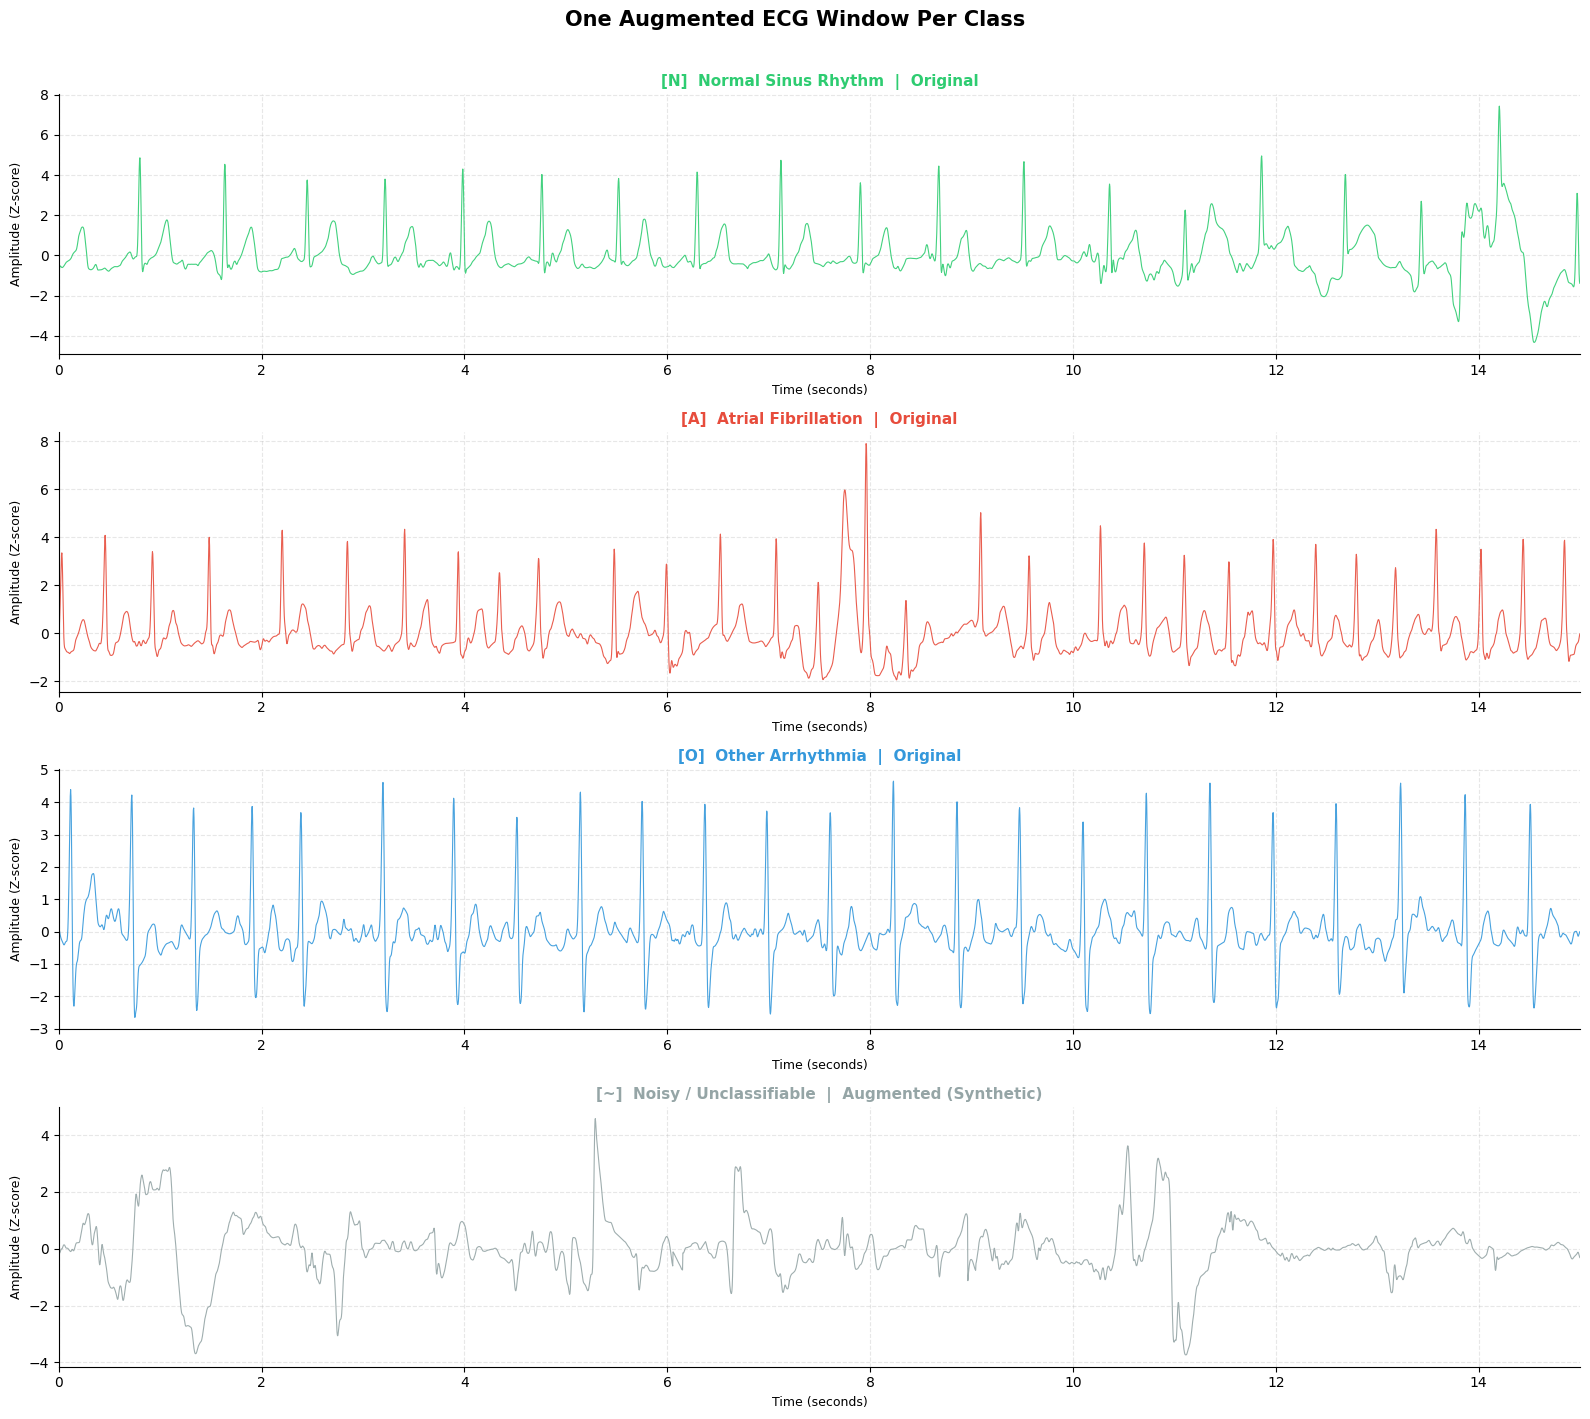

In [ ]:
import matplotlib.pyplot as plt
import numpy as np

def visualize_augmented_per_class(train_augmented_df, fs=300, window_size=4500):
    """
    Plot one AUGMENTED ECG signal per class.
    Picks a sample that was synthetically generated (record_id == "AUG")
    for minority classes, and any sample for the majority class.
    """
    class_names  = {"N": "Normal Sinus Rhythm", "A": "Atrial Fibrillation",
                    "O": "Other Arrhythmia",    "~": "Noisy / Unclassifiable"}
    class_colors = {"N": "#2ecc71", "A": "#e74c3c", "O": "#3498db", "~": "#95a5a6"}
    label_order  = ["N", "A", "O", "~"]

    fig, axes = plt.subplots(4, 1, figsize=(16, 14), sharex=False)
    fig.suptitle("One Augmented ECG Window Per Class", fontsize=15, fontweight="bold", y=1.01)

    t = np.arange(window_size) / fs  # time axis in seconds

    for ax, label in zip(axes, label_order):
        all_class   = train_augmented_df[train_augmented_df["label"] == label]
        aug_samples = all_class[all_class["record_id"].str.startswith("AUG_")]

        # Prefer an augmented sample; fall back to real if it doesn't exist (like Normal class)
        subset = aug_samples if not aug_samples.empty else all_class
        is_aug = not aug_samples.empty

        if subset.empty:
            ax.set_title(f"{label} — No samples found", color="red")
            continue

        sample = subset.iloc[0]["signal"]

        ax.plot(t, sample, color=class_colors[label], linewidth=0.8, alpha=0.9)
        ax.set_title(
            f"[{label}]  {class_names[label]}  |  "
            f"{'Augmented (Synthetic)' if is_aug else 'Original'}",
            fontsize=11, fontweight="bold", color=class_colors[label]
        )
        ax.set_ylabel("Amplitude (Z-score)", fontsize=9)
        ax.set_xlabel("Time (seconds)", fontsize=9)
        ax.set_xlim([0, window_size / fs])
        ax.grid(True, alpha=0.3, linestyle="--")
        ax.spines["top"].set_visible(False)
        ax.spines["right"].set_visible(False)

    plt.tight_layout()
    plt.show()

visualize_augmented_per_class(train_augmented)

## Save the Processed files

In [ ]:
import os

SAVE_DIR = "ECG_Processed_Final"
os.makedirs(SAVE_DIR, exist_ok=True)

# Train (augmented)
np.save(f"{SAVE_DIR}/X_train.npy", X_train)   # shape: (N, 4500, 1)
np.save(f"{SAVE_DIR}/y_train.npy", y_train)   # shape: (N,)

# Test
np.save(f"{SAVE_DIR}/X_test.npy",  X_test)    # shape: (M, 4500, 1)
np.save(f"{SAVE_DIR}/y_test.npy",  y_test)    # shape: (M,)

# Metadata csv (labels and record IDs)
train_meta = train_augmented[["record_id", "window_id", "label", "label_id"]].copy()
test_meta  = test_windowed[["record_id",  "window_id", "label", "label_id"]].copy()

train_meta.to_csv(f"{SAVE_DIR}/train_meta.csv", index=False)
test_meta.to_csv(f"{SAVE_DIR}/test_meta.csv",   index=False)


print("=== Saved Files ===")
for fname in os.listdir(SAVE_DIR):
    fpath = os.path.join(SAVE_DIR, fname)
    size_mb = os.path.getsize(fpath) / (1024 ** 2)
    print(f"  {fname:<25} {size_mb:>8.1f} MB")

print(f"\nX_train: {X_train.shape}  y_train: {y_train.shape}")
print(f"X_test:  {X_test.shape}   y_test:  {y_test.shape}")

# Code to Load back and use in other notebooks
# X_train = np.load("ECG_Processed_Final/X_train.npy")
# y_train = np.load("ECG_Processed_Final/y_train.npy")
# X_test  = np.load("ECG_Processed_Final/X_test.npy")
# y_test  = np.load("ECG_Processed_Final/y_test.npy")

=== Saved Files ===
  test_meta.csv                  0.1 MB
  train_meta.csv                 0.3 MB
  X_test.npy                   190.5 MB
  X_train.npy                  768.2 MB
  y_test.npy                     0.0 MB
  y_train.npy                    0.2 MB

X_train: (22376, 4500, 1)  y_train: (22376,)
X_test:  (5548, 4500, 1)   y_test:  (5548,)
